# Datenübersicht – Staffing Project BBA
Visualisierung der geladenen Zeitreihendaten aus NeonDB.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from dotenv import load_dotenv
from etl.db import engine

load_dotenv()
plt.rcParams['figure.figsize'] = (14, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

## 1. Besucherzahlen Stadtteilbücherei Hubland

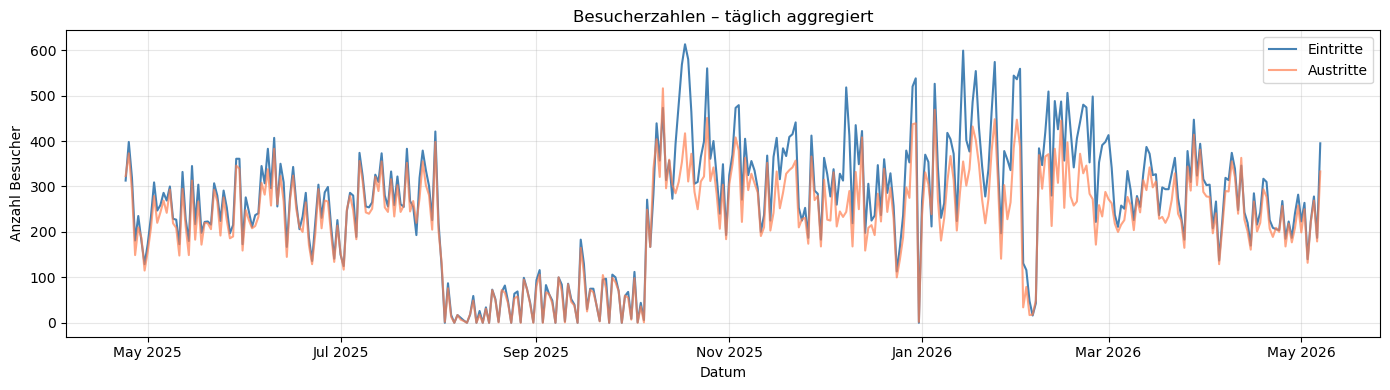

Zeitraum: 2025-04-24 bis 2026-05-07
Datenpunkte: 5499


In [2]:
library = pd.read_sql("""
    SELECT timestamp_local, count_enter, count_exit
    FROM raw.library_visitors
    ORDER BY timestamp_local
""", engine, parse_dates=['timestamp_local'])

# Tagessummen
library_daily = library.set_index('timestamp_local').resample('D').sum()

fig, ax = plt.subplots()
ax.plot(library_daily.index, library_daily['count_enter'], label='Eintritte', color='steelblue')
ax.plot(library_daily.index, library_daily['count_exit'], label='Austritte', color='coral', alpha=0.7)
ax.set_title('Besucherzahlen – täglich aggregiert')
ax.set_xlabel('Datum')
ax.set_ylabel('Anzahl Besucher')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.legend()
plt.tight_layout()
plt.show()
print(f"Zeitraum: {library['timestamp_local'].min().date()} bis {library['timestamp_local'].max().date()}")
print(f"Datenpunkte: {len(library)}")

## 2. Wetterdaten

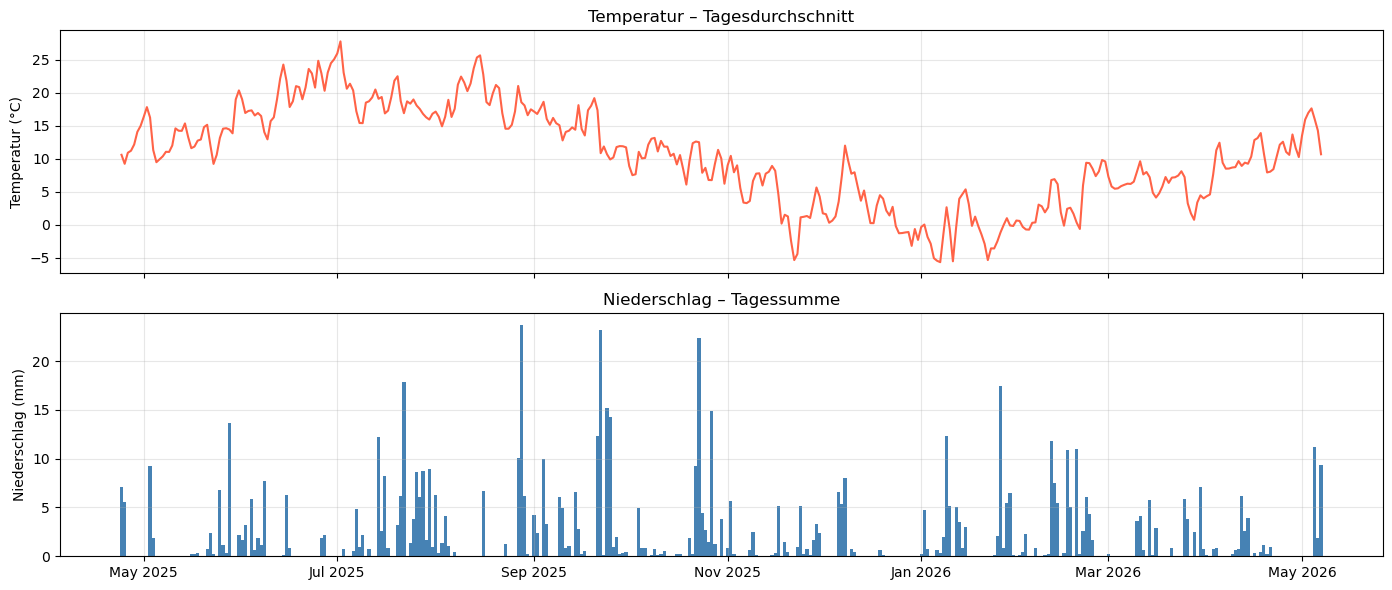

Datenpunkte: 9096


In [3]:
weather = pd.read_sql("""
    SELECT timestamp_local, temperature_c, precipitation_mm
    FROM raw.weather
    ORDER BY timestamp_local
""", engine, parse_dates=['timestamp_local'])

weather_daily = weather.set_index('timestamp_local').resample('D').agg(
    {'temperature_c': 'mean', 'precipitation_mm': 'sum'}
)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

ax1.plot(weather_daily.index, weather_daily['temperature_c'], color='tomato')
ax1.set_title('Temperatur – Tagesdurchschnitt')
ax1.set_ylabel('Temperatur (°C)')

ax2.bar(weather_daily.index, weather_daily['precipitation_mm'], color='steelblue', width=1)
ax2.set_title('Niederschlag – Tagessumme')
ax2.set_ylabel('Niederschlag (mm)')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.tight_layout()
plt.show()
print(f"Datenpunkte: {len(weather)}")

## 3. Feiertage & Schulferien

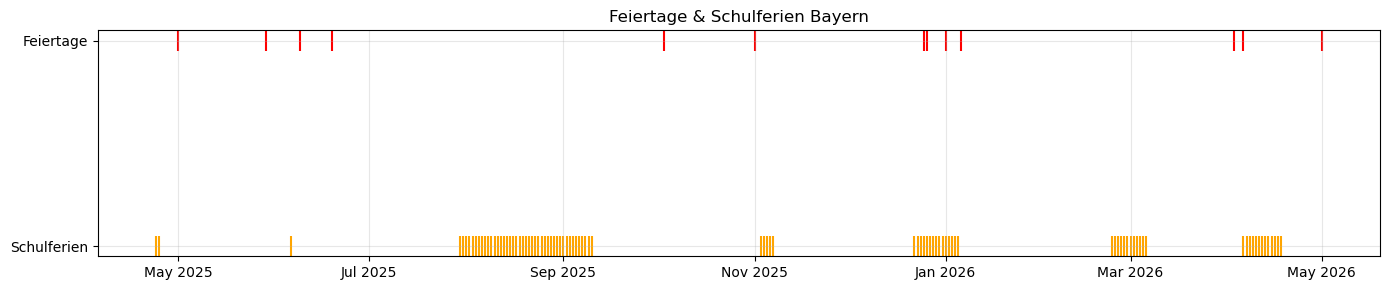

Feiertage: 13 | Schulferientage: 91


In [4]:
holidays = pd.read_sql("""
    SELECT date_local, is_public_holiday, is_school_holiday, holiday_name
    FROM processed.holidays
    ORDER BY date_local
""", engine, parse_dates=['date_local'])

public  = holidays[holidays['is_public_holiday']]
school  = holidays[holidays['is_school_holiday']]

fig, ax = plt.subplots(figsize=(14, 3))
ax.scatter(school['date_local'],  [1] * len(school),  label='Schulferien',  color='orange', marker='|', s=200)
ax.scatter(public['date_local'],  [2] * len(public),  label='Feiertage',    color='red',    marker='|', s=200)
ax.set_yticks([1, 2])
ax.set_yticklabels(['Schulferien', 'Feiertage'])
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.set_title('Feiertage & Schulferien Bayern')
plt.tight_layout()
plt.show()
print(f"Feiertage: {len(public)} | Schulferientage: {len(school)}")